In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
# definindo os caminhos
data_path = os.getenv('DATA_PATH')
plots_path = os.getenv('PLOTS_PATH')
results_path = os.getenv('RESULTS_PATH')

In [4]:
# carregando dataset model1_dataset
df = pd.read_parquet(data_path + '/model1_dataset.parquet')
df.head()

,player_id,date,market_value_in_eur,height_in_cm,international_caps,international_goals,national_team_ranking_inv,position_rank,sub_pos_Attacking Midfield,sub_pos_Central Midfield,...,assists_per_90,minutes_per_game,squad_size,net_transfer_record,national_team_players,stadium_seats,league_tier,club_computed_market_value,year,log_market_value
0,3132,2003-12-09,400000,168.0,0.0,0.0,0,3,True,False,...,0.0,0.0,25,-3750000.0,8,14879,4,400000,2003,12.899222
1,6893,2003-12-15,900000,188.0,0.0,0.0,0,2,False,False,...,0.0,0.0,25,-1350000.0,4,26850,1,900000,2003,13.710151
2,14007,2004-10-04,750000,177.0,0.0,0.0,0,3,False,False,...,0.0,0.0,26,900000.0,8,18360,1,67650000,2004,13.527830
3,13957,2004-10-04,2000000,182.0,0.0,0.0,0,1,False,False,...,0.0,0.0,0,-0.0,0,5441,4,2900000,2004,14.508658
4,13952,2004-10-04,2000000,175.0,0.0,0.0,0,4,False,False,...,0.0,0.0,27,-24490000.0,12,50033,4,18050000,2004,14.508658


In [5]:
# ordenando por jogador e data para cálculo temporal
df.sort_values(['player_id', 'date'], inplace=True)

In [6]:
# simulando predição perfeita usando a valuation imediatamente anterior do jogador
df['prev_market_value'] = df.groupby('player_id')['market_value_in_eur'].shift(1)

In [7]:
# mantendo apenas os registros que possuem valuation anterior válida
df_sim = df[(df['prev_market_value'].notna()) & (df['prev_market_value'] > 0)].copy()
df_sim.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480643 entries, 1689 to 510060
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   player_id                   480643 non-null  int64         
 1   date                        480643 non-null  datetime64[ns]
 2   market_value_in_eur         480643 non-null  int64         
 3   height_in_cm                480643 non-null  float64       
 4   international_caps          480643 non-null  float64       
 5   international_goals         480643 non-null  float64       
 6   national_team_ranking_inv   480643 non-null  int64         
 7   position_rank               480643 non-null  int64         
 8   sub_pos_Attacking Midfield  480643 non-null  bool          
 9   sub_pos_Central Midfield    480643 non-null  bool          
 10  sub_pos_Centre-Back         480643 non-null  bool          
 11  sub_pos_Centre-Forward      480643 non-nu

In [8]:
# calculando erro percentual absoluto (ape) de cada registro
val = df_sim['market_value_in_eur'].values
pred = df_sim['prev_market_value'].values
df_sim['ape'] = np.abs((val - pred) / (val + 1e-6)) * 100

In [9]:
# agrupando os jogadores por faixas de valor de mercado
bins = [0, 200_000, 500_000, 2_000_000, 10_000_000, np.inf]
labels = ['<200K', '200K-500K', '500K-2M', '2M-10M', '>10M']
df_sim['value_tier'] = pd.cut(df_sim['market_value_in_eur'], bins=bins, labels=labels)
df_sim['value_tier'].value_counts()

value_tier
500K-2M      176992
200K-500K    152312
2M-10M        95628
>10M          29933
<200K         25778
Name: count, dtype: int64

In [10]:
# calculando o mape agregado por cada faixa de valor
df_mape = df_sim.groupby('value_tier', observed=True)['ape'].mean().reset_index()
df_mape.rename(columns={'ape': 'mape'}, inplace=True)
df_mape

,value_tier,mape
0,<200K,20.381042
1,200K-500K,19.717838
2,500K-2M,22.626897
3,2M-10M,20.899834
4,>10M,15.563963


/tmp/ipykernel_9806/4202030370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mape, x='value_tier', y='mape', palette='viridis')


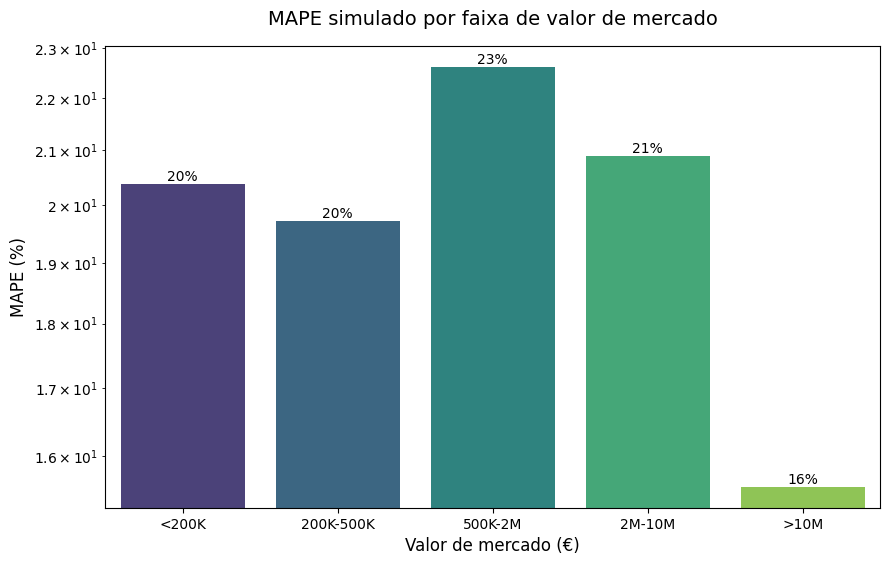

In [11]:
# plotando e salvando o mape por faixa de valor
plt.figure(figsize=(10, 6))
sns.barplot(data=df_mape, x='value_tier', y='mape', palette='viridis')

# customização de títulos e eixos
plt.title('MAPE simulado por faixa de valor de mercado', fontsize=14, pad=15)
plt.xlabel('Valor de mercado (€)', fontsize=12)
plt.ylabel('MAPE (%)', fontsize=12)
plt.yscale('log')

# adicionando os valores textuais acima das barras
for i, row in df_mape.iterrows():
    plt.text(i, row['mape'], f"{row['mape']:,.0f}%", ha='center', va='bottom')

# exibe o gráfico e salva
plt.savefig(plots_path + '/mape_diagnosis_by_tier.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# salvando as estatísticas do diagnóstico
stats = {
    "total_records_simulated": len(df_sim),
    "mape_by_tier": df_mape.set_index('value_tier')['mape'].to_dict()
}
with open(results_path + '/mape_diagnosis.json', 'w') as f:
    json.dump(stats, f, indent=2)

Esse notebook foi feito com o objetivo de descobrir o motivo do altíssimo valor do MAPE. A divisão por valores baixos de mercado é a causa da explosão artificial no MAPE, onde pequenos desvios absolutos geram erros percentuais de centenas ou milhares de por cento. O diagnóstico mostra que mesmo uma predição quase perfeita (usar o valor anterior do próprio jogador) gera MAPE de ~31% na faixa abaixo de €200K, ~23% na faixa €200K–€500K e ~23% na faixa €500K–€2M. Isso significa que, para atingir a meta de MAPE < 20%, o corte mínimo necessário é de €500K, valores abaixo disso geram erros percentuais matematicamente inevitáveis, independente da qualidade do modelo. O corte em €500K remove apenas jogadores com pouca relevância no mercado de transferências profissional (jogadores de base ou categorias amadoras), preservando todos os perfis de jogadores que são alvo de negociações reais.